In [64]:
import geopandas as gpd
from rasterstats import zonal_stats
import rasterio
import fiona
from pathlib import Path
import sys
import tempfile

ROOT = Path.cwd().parent #obtener raiz del proyecto 


if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from utils.gbif_process import (
    gbif_occurrence_search,
    gbif_fetch_all,
    gbif_to_dataframe,
    gbif_to_csv
)



In [65]:
# Cargar Capas de la base de datso Geoespacial
gdb_path = "../data/boundaries/raw/hnd_admin_boundaries.gdb"
capas = fiona.listlayers(gdb_path)

#Mostrar capas
#Acorde a la metadata la capa admin1 tiene departemtnos. y admin2 muncipios
#
for i, capa in enumerate(capas):
    print(f"[{i}] {capa}")
    
deptos = gpd.read_file(gdb_path, layer=capas[2])

tif_path = "../data/GIS_Data_SolarPower/raw/Honduras_GISdata_LTAy_YearlyMonthlyTotals_GlobalSolarAtlas-v2_GEOTIFF/GHI.tif"

[0] hnd_admin0
[1] hnd_admin1
[2] hnd_admin2
[3] hnd_adminlines
[4] hnd_adminpoints
[5] hnd_populatedplaces


In [68]:


stats = zonal_stats(
    vectors=deptos, 
    raster=tif_path, 
    stats=["mean", "min", "max", "count"], 
    geojson_out=True,
    all_touched=False # asegura precisión estricta: el centro del píxel debe estar dentro de la frontera
)

In [69]:
# 4. Transformar los resultados en un GeoDataFrame estructurado
import pandas as pd
resultados_ghi = gpd.GeoDataFrame.from_features(stats)

#Revisar las columnas de la layer
print(resultados_ghi.columns)

# Mostrar el departamento y su promedio exacto de irradiación
print(resultados_ghi[['adm1_name','adm2_name','mean','min','max','adm1_pcode','adm2_pcode']])


columnas = {
    'adm1_name': 'departamento',
    'adm2_name': 'municipio',
    'mean': 'mean',
    'min': 'min',
    'max': 'max',
    'adm1_pcode': 'codigo_departamental',
    'adm2_pcode': 'codigo_municipal'
}

columnas_texto= ['departamento', 'municipio']
df = pd.DataFrame(resultados_ghi.drop(columns=['geometry'], errors='ignore'))
df= df[list(columnas.keys())].rename(columns=columnas)

for col in columnas_texto:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()                          # Elimina espacios al inicio y final
        .str.replace(r'\s+', ' ', regex=True) # Reemplaza múltiples espacios por uno solo
        .str.title()                          # (Opcional) Normaliza a formato "Nombre Propio"
    )

df.to_csv("../data/GIS_Data_SolarPower/processed/yearly_monthly_totals.csv",index=False, encoding='utf-8-sig')


Index(['geometry', 'adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3',
       'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3',
       'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3',
       'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang',
       'lang1', 'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon',
       'min', 'max', 'mean', 'count'],
      dtype='str')
             adm1_name              adm2_name         mean          min  \
0    Islas de La Bahia                Guanaja  1988.934501  1898.935059   
1    Islas de La Bahia  Jose Santos Guardiola  2012.974138  1978.923950   
2    Islas de La Bahia                 Roatan  2009.962306  1982.577026   
3                Colon               Trujillo  1964.558803  1748.086060   
4                Colon                 Iriona  1791.207199  1471.227051   
..                 ...                    ...          ...          ...   
293     Gracias a Dios             

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def graficos_irradiacion(df):

    # ==========================================================
    # 1. BARRAS - IRRADIACIÓN POR MUNICIPIO EN CORTÉS
    # ==========================================================

    cortes = df[
        df["departamento"]
        .str.strip()
        .str.lower()
        == "cortes"
    ].copy()

    cortes = cortes.sort_values("mean", ascending=False)

    plt.figure(figsize=(12, 6))

    # Un color diferente para cada municipio
    colores = plt.cm.tab20(np.linspace(0, 1, len(cortes)))

    bars = plt.bar(
        cortes["municipio"],
        cortes["mean"],
        color=colores
    )

    plt.title("Irradiación solar promedio por municipio - Cortés")
    plt.xlabel("Municipio")
    plt.ylabel("GHI promedio (kWh/m²/año)")
    plt.xticks(rotation=45, ha="right")

    # Valores sobre las barras
    for bar, valor in zip(bars, cortes["mean"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{valor:,.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


    # ==========================================================
    # 2. HISTOGRAMA - DEPARTAMENTO HN05
    # ==========================================================

    departamento_05 = df[
        df["codigo_departamental"]
        .astype(str)
        .str.strip()
        == "HN05"
    ].copy()

    datos = departamento_05["mean"].dropna()

    # Estadísticos
    media = datos.mean()
    desviacion = datos.std()
    varianza = datos.var()

    plt.figure(figsize=(10, 6))

    plt.hist(
        datos,
        bins=10,
        edgecolor="black",
        alpha=0.75
    )

    # Línea de la media
    plt.axvline(
        media,
        linestyle="--",
        linewidth=2,
        label=f"Media = {media:,.2f}"
    )

    # Estadísticos dentro del gráfico
    texto = (
        f"Media: {media:,.2f}\n"
        f"Desv. estándar: {desviacion:,.2f}\n"
        f"Varianza: {varianza:,.2f}"
    )

    plt.text(
        0.97,
        0.95,
        texto,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85
        )
    )

    plt.title(
        "Distribución de irradiación solar - Departamento HN05"
    )
    plt.xlabel("GHI promedio (kWh/m²/año)")
    plt.ylabel("Frecuencia")

    plt.legend()
    plt.tight_layout()
    plt.show()

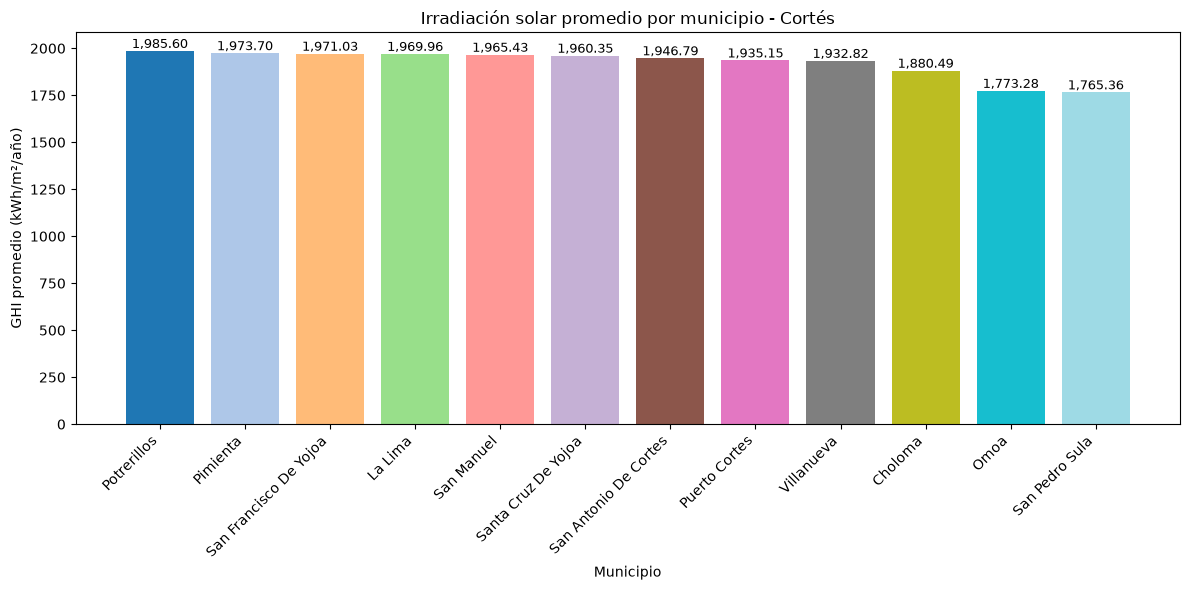

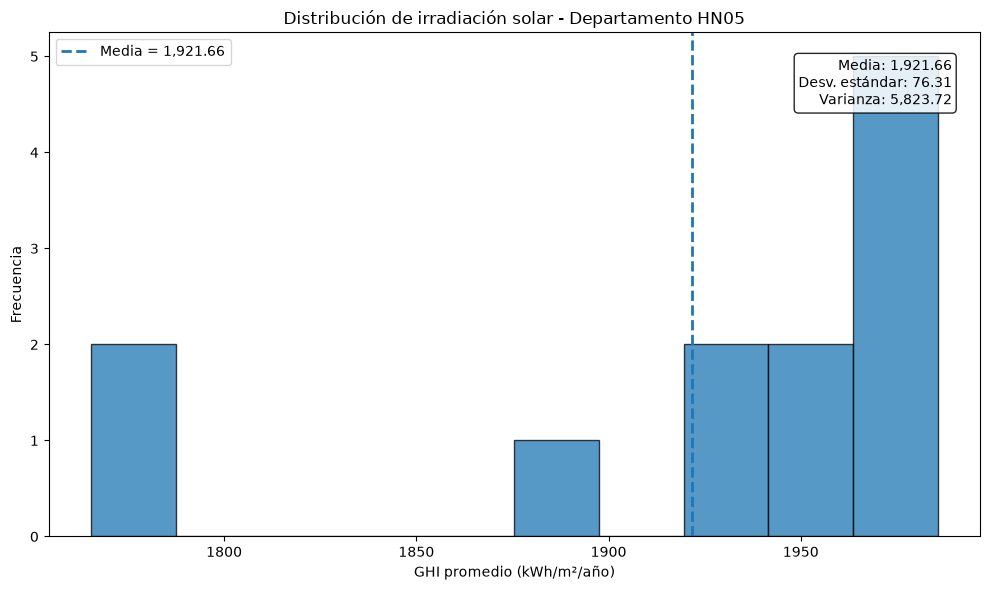

In [59]:

graficos_irradiacion(df)

In [45]:
#df = gbif_to_csv(
#    records,
#    "data/gbif/puerto_cortes.csv"
#)

#print(df.head())